In [1]:
import os
import kagglehub

if os.path.exists("/content"):

    from google.colab import drive

    drive.mount("/content/drive")

    output_dir = "/content/drive/MyDrive/sample data"

    path = kagglehub.dataset_download(
        "apollo2506/eurosat-dataset",
        output_dir=output_dir
    )

    print("Running on Google Colab")
    print("Dataset path:", path)

else:

    path = kagglehub.dataset_download(
        "apollo2506/eurosat-dataset"
    )

    print("Running locally")
    print("Dataset path:", path)

Running locally
Dataset path: C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6


In [2]:
import os
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
torch.manual_seed(42)

In [3]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:2])
    print("Files:", files[:2])
    print()
    break
  

C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6
Folders: ['EuroSAT', 'EuroSATallBands']
Files: []



In [4]:
def create_dataset(data_dir):
    images = []
    labels = []

    class_names = sorted(os.listdir(data_dir))
    for label, c_name in enumerate(class_names):
        class_dir = os.path.join(data_dir,c_name)

        if os.path.isdir(class_dir):
            print(class_dir)
            for image_name in os.listdir(class_dir):
                image_path = os.path.join(class_dir,image_name)

                images.append(image_path)
                labels.append(label)

    return images, labels

In [5]:
#data_dir= "/kaggle/input/eurosat-dataset/EuroSAT"
data_dir = os.path.join(path,"EuroSAT")
os.listdir(data_dir)

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'label_map.json',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake',
 'test.csv',
 'train.csv',
 'validation.csv']

In [6]:
sorted(os.listdir(data_dir))

['AnnualCrop',
 'Forest',
 'HerbaceousVegetation',
 'Highway',
 'Industrial',
 'Pasture',
 'PermanentCrop',
 'Residential',
 'River',
 'SeaLake',
 'label_map.json',
 'test.csv',
 'train.csv',
 'validation.csv']

In [7]:
X, y = create_dataset(data_dir)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\AnnualCrop
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Forest
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\HerbaceousVegetation
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Highway
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Industrial
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Pasture
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\PermanentCrop
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\Residential
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\EuroSAT\River
C:\Users\Dilip Das\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6\

In [8]:
len(X), len(y)

(27000, 27000)

In [9]:
print(len(set(y)))
total_classes = len(set(y))

10


In [10]:
X[:5], y[:5]

(['C:\\Users\\Dilip Das\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_1.jpg',
  'C:\\Users\\Dilip Das\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_10.jpg',
  'C:\\Users\\Dilip Das\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_100.jpg',
  'C:\\Users\\Dilip Das\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_1000.jpg',
  'C:\\Users\\Dilip Das\\.cache\\kagglehub\\datasets\\apollo2506\\eurosat-dataset\\versions\\6\\EuroSAT\\AnnualCrop\\AnnualCrop_1001.jpg'],
 [0, 0, 0, 0, 0])

In [11]:
print(np.array(Image.open(X[1])).shape)

(64, 64, 3)


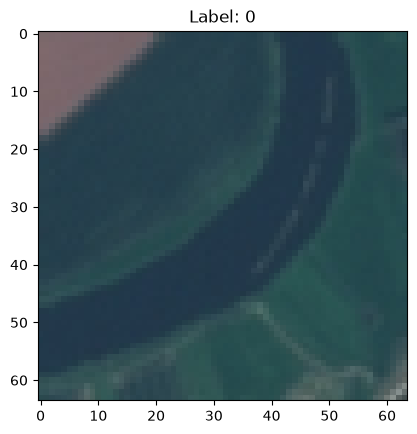

In [12]:
from PIL import Image
import matplotlib.pyplot as plt


img = Image.open(X_train[515]).convert("RGB")

plt.imshow(img)
plt.title(f"Label: {y_train[0]}")

plt.show()


In [13]:
class eurosat(Dataset):

    def __init__(self, images, labels, transforms = None):

        self.images = images
        self.labels = labels

        self.transforms = transforms

    def __len__(self):
        lenght = len(self.images)
        return lenght

    def __getitem__(self, index):
        image_path = self.images[index]
        image = Image.open(image_path).convert("RGB")

        labels = self.labels[index]

        if self.transforms:
            image = self.transforms(image)

        return image, labels

In [14]:
train_transformation = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    

test_transformation = transforms.Compose([
    transforms.Resize(256),       
    transforms.CenterCrop(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
train_dataset = eurosat(X_train, y_train, transforms = train_transformation)
test_dataset = eurosat(X_test, y_test, transforms = test_transformation)


train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [16]:
import torchvision.models as models

vgg = models.vgg16(pretrained = True)


d:\Ana\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Ana\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
vgg.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [18]:
for params in vgg.features.parameters():
    params.requires_grad = False

In [19]:
vgg.classifier = nn.Sequential(
    nn.Linear(25088, 2025, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(2025, 2025, bias = True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(2025, 256, bias = True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(256, 10, bias = True)
)

In [20]:
vgg.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=2025, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=2025, out_features=2025, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=2025, out_features=256, bias=True)
  (7): ReLU(inplace=True)
  (8): Dropout(p=0.5, inplace=False)
  (9): Linear(in_features=256, out_features=10, bias=True)
)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
vgg.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [23]:
import torch.optim as optim
learning_rate = 0.0001
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    vgg.classifier.parameters(), 
    lr=learning_rate,               
    weight_decay=0.0005 # L2 regularization to prevent overfitting
)

In [24]:
print(device)

cuda


In [27]:
train_losses = []
train_accuracies = []
for epoch in range(epochs):
    total_epochs_loss = 0
    correct = 0
    total = 0



    for batch_features, batch_labels in train_dataloader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.long().to(device)
        output = vgg(batch_features)
        loss = criterion(output, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        total_epochs_loss = total_epochs_loss + loss.item()
        predicted = output.argmax(dim=1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

    avg_loss = total_epochs_loss/len(train_dataloader)
    accuracy = 100 * correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.8083975756609881
Epoch: 2 , Loss: 0.42642509763991393
Epoch: 3 , Loss: 0.3771119205598478
Epoch: 4 , Loss: 0.34835042115714815
Epoch: 5 , Loss: 0.33818013440679623
Epoch: 6 , Loss: 0.33285264630008626
Epoch: 7 , Loss: 0.32048784223971544
Epoch: 8 , Loss: 0.3142807355191973
Epoch: 9 , Loss: 0.30552648316103
Epoch: 10 , Loss: 0.30582974614368547


In [ ]:
correct = 0
total = 0

vgg.eval()

with torch.no_grad():

    for batch_features, batch_labels in train_dataloader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.long().to(device)

        output = vgg(batch_features)

        predicted = output.argmax(dim=1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total

print(f"Training Accuracy: {accuracy:.2f}%")

Training Accuracy: 92.34%


In [ ]:
correct = 0
total = 0

vgg.eval()

with torch.no_grad():

    for batch_features, batch_labels in test_dataloader:
        batch_features = batch_features.to(device)

        #print(batch_features.shape)

        batch_labels = batch_labels.long().to(device)

        output = vgg(batch_features)

        #print(output.shape)
        

        predicted = output.argmax(dim=1)
        
        #print(predicted.shape)
        
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum()

accuracy = 100 * correct / total

print(f"Testing Accuracy: {accuracy:.2f}%")

Testing Accuracy: 93.26%


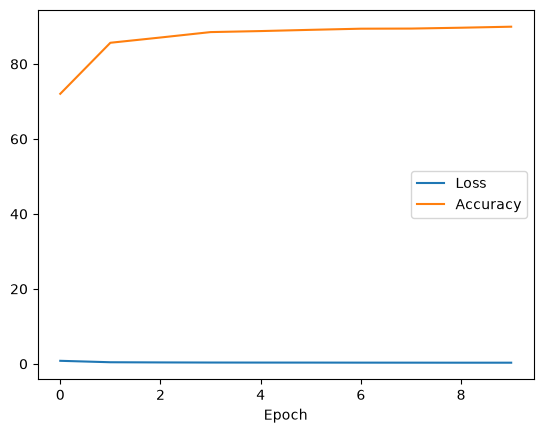

In [28]:
plt.plot(train_losses, label="Loss")
plt.plot(train_accuracies, label="Accuracy")

plt.xlabel("Epoch")
plt.legend()
plt.show()